# Acoustic geometry self-calibration (Q1 DREGON, Q2 Michael's)

Bundle-adjust microphone (and optionally rotor) positions so the single-source
free-field `1/r + delay` model best explains the measured multichannel field in
the coherent band. Reusable logic lives in `geom_calibration.py`
(built on `stage0_rtf_utils.py`).

**Sign trap found & fixed:** `scipy.signal.csd` (in `estimate_rtf`) carries the
*opposite* phase sign to `freefield_rtf` / `gcc_phat`. Comparing phases without
correcting this inflates the nominal residual from ~38 deg to ~93 deg. The
DREGON path negates the `estimate_rtf` phase; the Michael's path builds
`X_m·conj(X_ref)` directly (already free-field sign).

In [1]:
import os, sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

here = Path.cwd()
repo = next(b for b in [here, *here.parents] if (b/"data"/"DREGON").is_dir() and (b/"src").is_dir())
sys.path.insert(0, str(repo/"src"))
sys.path.insert(0, str(here))
os.environ.setdefault("DATA_ROOT", str(repo/"data"))
import warnings; warnings.filterwarnings("ignore")

import stage0_rtf_utils as s0
import geom_calibration as gc
print("repo:", repo)

repo: /home/flyingleafe/Research/PhD/projects/harmonic-noise-suppression


## Q1 — DREGON position self-calibration

Single-motor constant-speed recordings (speeds 60/70/80 Hz), coherent band 400-800 Hz, starting from the 183 deg-corrected nominal frame.

In [2]:
res = gc.calibrate_dregon_positions(speeds=(60,70,80), band=(400.0,800.0), lam=50.0)
print(f"phase resid (all coh)  {res.resid_before_deg:5.1f} -> {res.resid_after_deg:5.1f} deg")
print(f"phase resid (coh>=0.8) {res.resid_before_deg_hi:5.1f} -> {res.resid_after_deg_hi:5.1f} deg")
print(f"TDOA correlation       {res.tdoa_corr_before:5.3f} -> {res.tdoa_corr_after:5.3f}")
print(f"|RTF| mean|err| dB     {res.mag_err_before_db:5.2f} -> {res.mag_err_after_db:5.2f}")
print("per-mic delta (raw)      cm:", np.round(res.mic_delta_cm,2))
print("per-mic delta (procrustes)cm:", np.round(res.mic_delta_procrustes_cm,2))
print(f"max/mean delta: {res.mic_delta_cm.max():.2f} / {res.mic_delta_cm.mean():.2f} cm")

phase resid (all coh)   38.3 ->  28.8 deg
phase resid (coh>=0.8)  34.0 ->  24.6 deg
TDOA correlation       0.892 -> 0.876
|RTF| mean|err| dB      2.41 ->  2.52
per-mic delta (raw)      cm: [0.66 0.88 0.48 2.17 0.56 1.7  0.5  2.19]
per-mic delta (procrustes)cm: [0.71 0.85 0.55 2.13 0.64 1.68 0.61 2.13]
max/mean delta: 2.19 / 1.14 cm


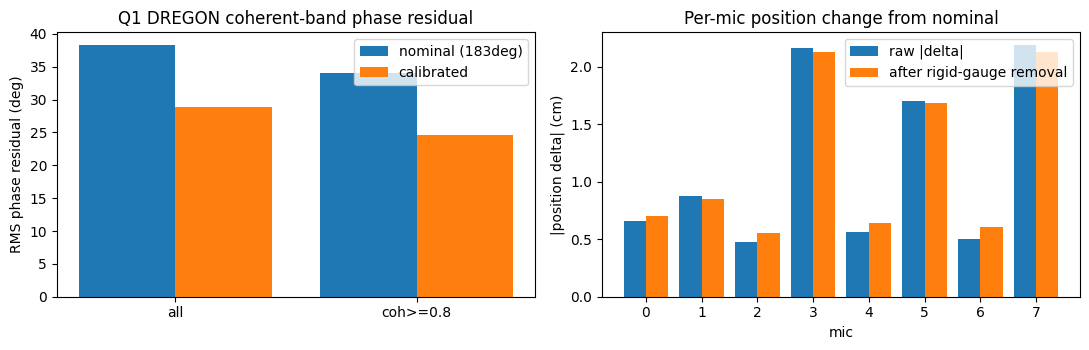

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(11,3.6))
lbl=["all","coh>=0.8"]
b=[res.resid_before_deg,res.resid_before_deg_hi]; a=[res.resid_after_deg,res.resid_after_deg_hi]
x=np.arange(2)
ax[0].bar(x-0.2,b,0.4,label="nominal (183deg)"); ax[0].bar(x+0.2,a,0.4,label="calibrated")
ax[0].set_xticks(x); ax[0].set_xticklabels(lbl); ax[0].set_ylabel("RMS phase residual (deg)")
ax[0].set_title("Q1 DREGON coherent-band phase residual"); ax[0].legend()
m=np.arange(8)
ax[1].bar(m-0.2,res.mic_delta_cm,0.4,label="raw |delta|")
ax[1].bar(m+0.2,res.mic_delta_procrustes_cm,0.4,label="after rigid-gauge removal")
ax[1].set_xlabel("mic"); ax[1].set_ylabel("|position delta| (cm)")
ax[1].set_title("Per-mic position change from nominal"); ax[1].legend()
plt.tight_layout(); plt.show()

### Measured vs free-field phase (one rotor), before vs after
Each point is a high-coherence frequency bin; a perfect model lies on the diagonal.

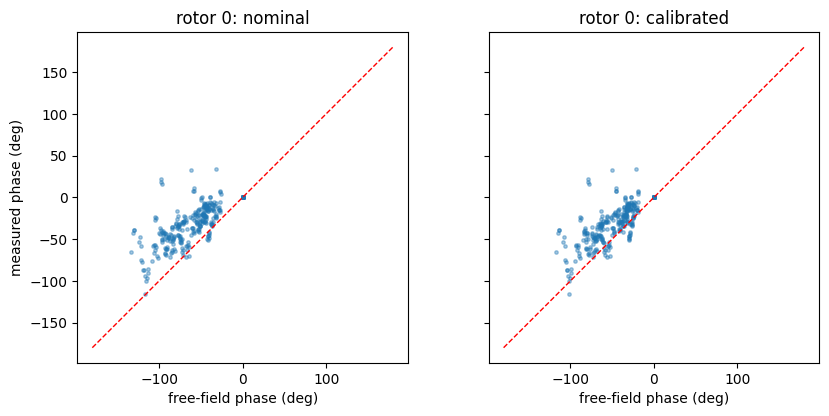

In [4]:
rc = res.records[1]  # rotor 0, one speed
sel = rc.coh.mean(0) > 0.7
def ff_phase(geom_mic, geom_rot):
    d = s0.distance_matrix(geom_mic, geom_rot)[rc.rotor]
    return np.angle(s0.freefield_rtf(rc.freqs, d, rc.ref))
ph_meas = rc.meas_phase[:, sel].ravel()
ph_nom = ff_phase(res.mic_init, res.rotor_init)[:, sel].ravel()
ph_opt = ff_phase(res.mic_opt, res.rotor_opt)[:, sel].ravel()
wrap=lambda x:(x+np.pi)%(2*np.pi)-np.pi
fig,ax=plt.subplots(1,2,figsize=(9,4.2),sharex=True,sharey=True)
for a_,p,ttl in zip(ax,[ph_nom,ph_opt],["nominal","calibrated"]):
    a_.scatter(np.degrees(wrap(p)),np.degrees(ph_meas),s=6,alpha=.4)
    a_.plot([-180,180],[-180,180],'r--',lw=1); a_.set_title(f"rotor {rc.rotor}: {ttl}")
    a_.set_xlabel("free-field phase (deg)"); a_.set_aspect('equal')
ax[0].set_ylabel("measured phase (deg)")
plt.tight_layout(); plt.show()

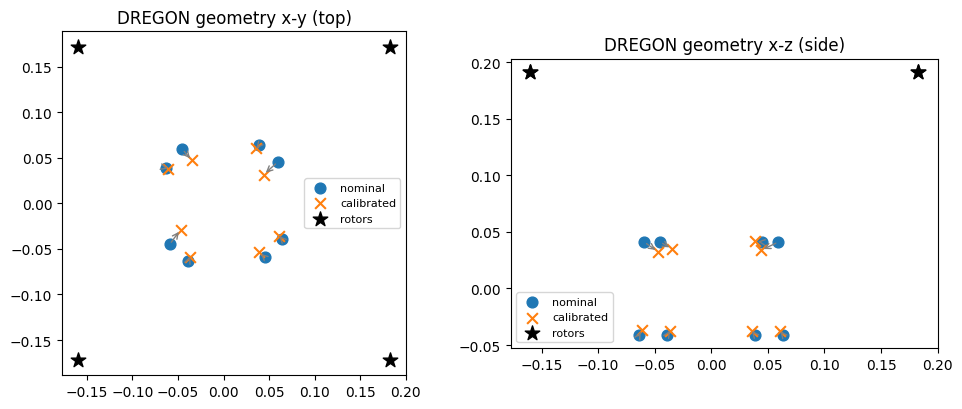

In [5]:
fig,ax=plt.subplots(1,2,figsize=(10,4.2))
for j,(i0,i1,t) in enumerate([(0,1,"x-y (top)"),(0,2,"x-z (side)")]):
    ax[j].scatter(res.mic_init[:,i0],res.mic_init[:,i1],c='C0',label='nominal',s=60)
    ax[j].scatter(res.mic_opt[:,i0],res.mic_opt[:,i1],c='C1',marker='x',label='calibrated',s=60)
    for m in range(8):
        ax[j].annotate("",xy=(res.mic_opt[m,i0],res.mic_opt[m,i1]),xytext=(res.mic_init[m,i0],res.mic_init[m,i1]),arrowprops=dict(arrowstyle="->",color='gray'))
    ax[j].scatter(res.rotor_init[:,i0],res.rotor_init[:,i1],c='k',marker='*',s=120,label='rotors')
    ax[j].set_title(f"DREGON geometry {t}"); ax[j].set_aspect('equal'); ax[j].legend(fontsize=8)
plt.tight_layout(); plt.show()

## Q2 — Michael's: indexing + geometry from audio only

No single-rotor recordings: the 4 rotors run simultaneously, separated by
**frequency** using per-rotor RPS telemetry (harmonics `k·2·rps_i(t)` isolated
from every other rotor's comb). Steps: (a) telemetry-gated per-rotor RTF,
(b) mic-indexing / frame-flip detection, (c) prior-anchored refinement.

In [6]:
mres, perm = gc.calibrate_michaels_positions(recording_index=0, windows=(40.,60.,80.), lam=20.0)
print("=== indexing / flip detection (FLY124) ===")
print(f"best roll : {perm.best_roll_name}  score {perm.best_roll_score:.3f}")
print(f"best flip : {perm.best_flip_name}  score {perm.best_flip_score:.3f}")
print(f"margin flip-roll: {perm.margin_flip_vs_roll:+.3f}  ->  flip_selected = {perm.flip_selected}")
print(f"selected z-rotation: {perm.selected_rotation_deg:.0f} deg")
print()
print(f"phase resid (all)  {mres.resid_before_deg:5.1f} -> {mres.resid_after_deg:5.1f} deg")
print(f"phase resid (hi)   {mres.resid_before_deg_hi:5.1f} -> {mres.resid_after_deg_hi:5.1f} deg")
print(f"TDOA correlation   {mres.tdoa_corr_before:5.3f} -> {mres.tdoa_corr_after:5.3f}")
print("per-rotor isolated bins:", [r.freqs.size for r in mres.records],
      "mean coh:", [round(float(r.coh.mean()),2) for r in mres.records])
print("delta cm (procrustes) max/mean:", round(mres.mic_delta_procrustes_cm.max(),2), round(mres.mic_delta_procrustes_cm.mean(),2))

=== indexing / flip detection (FLY124) ===
best roll : roll7  score 0.768
best flip : flip_roll1  score 0.748
margin flip-roll: -0.020  ->  flip_selected = False
selected z-rotation: 239 deg

phase resid (all)   51.3 ->  27.0 deg
phase resid (hi)    30.3 ->  16.9 deg
TDOA correlation   0.749 -> 0.905
per-rotor isolated bins: [180, 206, 195, 206] mean coh: [0.67, 0.57, 0.57, 0.55]
delta cm (procrustes) max/mean: 3.46 2.82


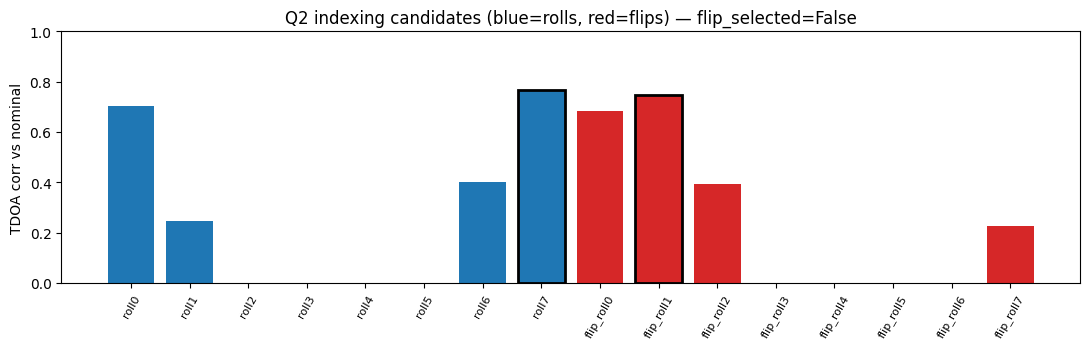

In [7]:
names=[f"roll{k}" for k in range(8)]+[f"flip_roll{k}" for k in range(8)]
vals=[perm.table[n] for n in names]
cols=['C0']*8+['C3']*8
fig,ax=plt.subplots(figsize=(11,3.6))
bars=ax.bar(range(16),vals,color=cols)
bars[names.index(perm.best_roll_name)].set_edgecolor('k'); bars[names.index(perm.best_roll_name)].set_linewidth(2)
bars[names.index(perm.best_flip_name)].set_edgecolor('k'); bars[names.index(perm.best_flip_name)].set_linewidth(2)
ax.set_xticks(range(16)); ax.set_xticklabels(names,rotation=60,fontsize=8)
ax.set_ylabel("TDOA corr vs nominal"); ax.set_ylim(0,1)
ax.set_title(f"Q2 indexing candidates (blue=rolls, red=flips) — flip_selected={perm.flip_selected}")
plt.tight_layout(); plt.show()

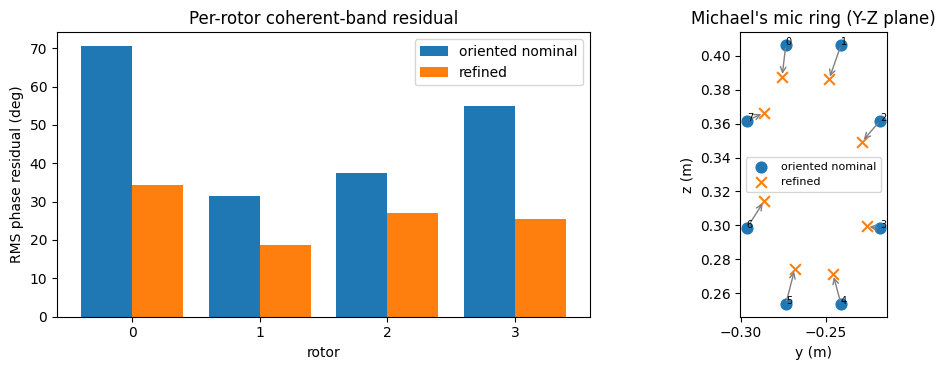

In [8]:
fig,ax=plt.subplots(1,2,figsize=(11,3.8))
# per-rotor residual before/after
rr_b=[gc.phase_residual_rms_deg([r], mres.mic_init, mres.rotor_init) for r in mres.records]
rr_a=[gc.phase_residual_rms_deg([r], mres.mic_opt, mres.rotor_opt) for r in mres.records]
x=np.arange(4)
ax[0].bar(x-0.2,rr_b,0.4,label="oriented nominal"); ax[0].bar(x+0.2,rr_a,0.4,label="refined")
ax[0].set_xticks(x); ax[0].set_xlabel("rotor"); ax[0].set_ylabel("RMS phase residual (deg)")
ax[0].set_title("Per-rotor coherent-band residual"); ax[0].legend()
# geometry y-z (ring plane)
ax[1].scatter(mres.mic_init[:,1],mres.mic_init[:,2],c='C0',s=60,label='oriented nominal')
ax[1].scatter(mres.mic_opt[:,1],mres.mic_opt[:,2],c='C1',marker='x',s=60,label='refined')
for m in range(8):
    ax[1].annotate("",xy=(mres.mic_opt[m,1],mres.mic_opt[m,2]),xytext=(mres.mic_init[m,1],mres.mic_init[m,2]),arrowprops=dict(arrowstyle="->",color='gray'))
    ax[1].annotate(str(m),(mres.mic_init[m,1],mres.mic_init[m,2]),fontsize=7)
ax[1].set_aspect('equal'); ax[1].set_xlabel("y (m)"); ax[1].set_ylabel("z (m)")
ax[1].set_title("Michael's mic ring (Y-Z plane)"); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

### Cross-check on the second recording (FLY125)
Independent recording should reproduce the same indexing decision and orientation.

In [9]:
mres2, perm2 = gc.calibrate_michaels_positions(recording_index=1, windows=(40.,60.,80.), lam=20.0)
print(f"FLY125 best roll {perm2.best_roll_name} ({perm2.best_roll_score:.3f}), best flip {perm2.best_flip_name} ({perm2.best_flip_score:.3f}), "
      f"flip_selected={perm2.flip_selected}, rot={perm2.selected_rotation_deg:.0f}deg")
print(f"FLY125 phase resid {mres2.resid_before_deg:.1f} -> {mres2.resid_after_deg:.1f} deg; "
      f"TDOA {mres2.tdoa_corr_before:.3f} -> {mres2.tdoa_corr_after:.3f}; "
      f"delta max/mean {mres2.mic_delta_procrustes_cm.max():.2f}/{mres2.mic_delta_procrustes_cm.mean():.2f} cm")

FLY125 best roll roll7 (0.775), best flip flip_roll1 (0.756), flip_selected=False, rot=239deg
FLY125 phase resid 47.3 -> 27.7 deg; TDOA 0.769 -> 0.898; delta max/mean 2.93/2.57 cm


## Caveats / identifiability

- **Low frequencies ⇒ small inter-mic phase ⇒ weakly constrained absolute
  positions.** The prior to the nominal geometry both regularises and fixes the
  gauge (global rotation/translation + reflection). Reported deltas are
  cm-scale; the Procrustes column removes residual rigid drift.
- **Q1 tension:** optimising the narrow 400-800 Hz phase can slightly trade off
  broadband GCC-PHAT TDOA and `|RTF|` magnitude (directivity / near-field the
  free-field model does not capture). Residual floor ~25 deg is model mismatch,
  not optimiser failure (synthetic recovery reaches ~0 deg).
- **Q2** robustly resolves indexing (no flip; ring re-clock `roll7`) and gross
  orientation; fine positions are only refined *within the prior*. Two rotors
  momentarily sharing an rps lose isolated bins — mitigated by averaging over
  several time windows.